In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load Dataset

df = pd.read_csv("housing.csv")

In [5]:
# Display First Five Records

print(df.head())

# Display Numerical Columns

print(df.select_dtypes(include="number").columns)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value  
0         322         126         8.3252              452600  
1        2401        1138         8.3014              358500  
2         496         177         7.2574              352100  
3         558         219         5.6431              341300  
4         565         259         3.8462              342200  
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
  

In [6]:
# Calculate Correlation Matrix

correlation = df.corr(numeric_only=True)
print(correlation)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071035      -0.079809   
housing_

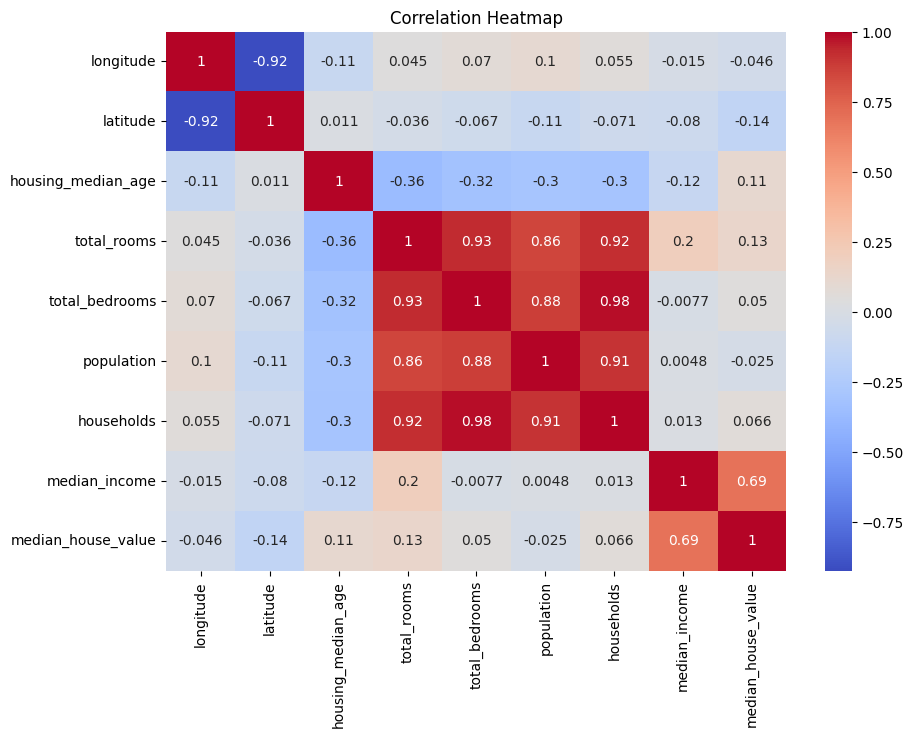

In [7]:
# Display Correlation Heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Practical 3B

In [11]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
# Load Dataset

df = pd.read_csv("housing.csv")

In [26]:
# Select Independent and Dependent Variables

X = df[["median_income"]]
y = df["median_house_value"]

In [27]:
# Split Dataset into Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [28]:
# Create Linear Regression Model

model = LinearRegression()

In [29]:
# Train the Model

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[41933.85]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['median_income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.446e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [15]:
# Display Coefficient and Intercept

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 41933.84939381274
Intercept: 44459.729169078666


In [21]:
# Predict House Values

y_pred = model.predict(X_test)

In [22]:
# Display First 10 Predictions

print("Predicted Values:")

print(y_pred[:10])

Predicted Values:
[114958.91676996 150606.88213964 190393.71844449 285059.38345102
 200663.31816103 242165.24890609 257647.22610228 199229.18051176
 245893.1681172  384677.43607096]


In [23]:
# Calculate Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 7091157771.76555


In [24]:
# Calculate R2 Score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.45885918903846656


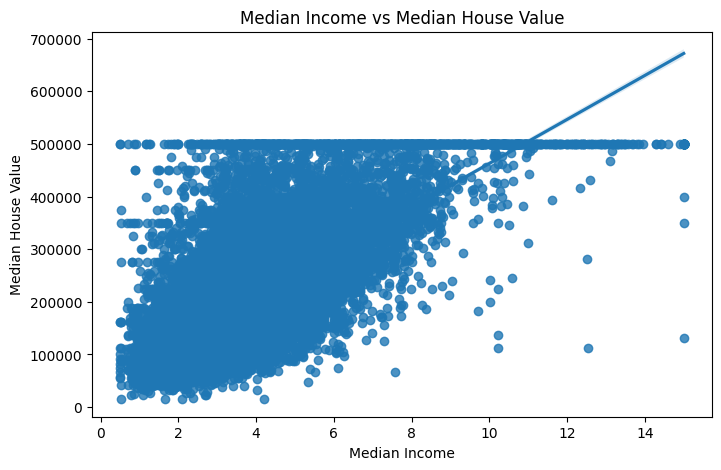

In [25]:
# Scatter Plot with Regression Line

plt.figure(figsize=(8, 5))

sns.regplot(
    x="median_income",
    y="median_house_value",
    data=df
)

plt.xlabel("Median Income")

plt.ylabel("Median House Value")

plt.title("Median Income vs Median House Value")

plt.show()

Extra Questions

In [30]:
import pandas as pd

# Load dataset
df = pd.read_csv("housing.csv")

# Select numerical columns
numerical_data = df.select_dtypes(include=["int64", "float64"])

# Correlation matrix
corr_matrix = numerical_data.corr()

print("Complete Correlation Matrix:\n")
print(corr_matrix)

# Remove self-correlation (1.0)
corr_copy = corr_matrix.copy()

for i in range(len(corr_copy)):
    corr_copy.iloc[i, i] = None

# Strongest positive correlation
max_corr = corr_copy.unstack().idxmax()
max_value = corr_copy.unstack().max()

# Strongest negative correlation
min_corr = corr_copy.unstack().idxmin()
min_value = corr_copy.unstack().min()

# Weakest correlation
weak_corr = corr_copy.abs().unstack().idxmin()
weak_value = corr_copy.abs().unstack().min()

print("\nStrongest Positive Correlation:")
print(max_corr, "=", max_value)

print("\nStrongest Negative Correlation:")
print(min_corr, "=", min_value)

print("\nWeakest Correlation:")
print(weak_corr, "=", weak_value)

Complete Correlation Matrix:

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("housing.csv")

# Multiple Regression
X_multi = df[
    [
        "median_income",
        "housing_median_age",
        "total_rooms",
        "population",
        "households"
    ]
]

y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y,
    test_size=0.2,
    random_state=42
)

model_multi = LinearRegression()

model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

print("Multiple Regression")

print("R2 Score:",
      r2_score(y_test, y_pred_multi))

print("Mean Squared Error:",
      mean_squared_error(y_test, y_pred_multi))

# Simple Regression

X_simple = df[["median_income"]]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

model_simple = LinearRegression()

model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

print("\nSimple Regression")

print("R2 Score:",
      r2_score(y_test, y_pred_simple))

print("Mean Squared Error:",
      mean_squared_error(y_test, y_pred_simple))

Multiple Regression
R2 Score: 0.5490012551168503
Mean Squared Error: 5909928044.702565

Simple Regression
R2 Score: 0.45885918903846656
Mean Squared Error: 7091157771.76555


In [32]:
import pandas as pd

# Load dataset
df = pd.read_csv("housing.csv")

correlation = df["total_rooms"].corr(
    df["median_house_value"]
)

print(
    "Correlation between total_rooms and median_house_value:"
)

print(correlation)

Correlation between total_rooms and median_house_value:
0.1341531138065631
